In [4]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B1 # Atualizado para B1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomTranslation, RandomBrightness, RandomZoom, Input
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 1. CONFIGURAÇÕES DA REDE NEURAL

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

PASTA_DATASET = '/content/drive/MyDrive/Dataset_Aves_Brasil_ampliado' # A pasta com as 216 (163) subpastas
TAMANHO_IMAGEM = (224, 224) # Tamanho exigido pelo MobileNet
TAMANHO_LOTE = 32 # O modelo vai ler e aprender de 32 em 32 imagens (Batch Size)


## 2. CARREGAMENTO DOS DADOS (TREINO E VALIDAÇÃO)

In [6]:
# Carrega 80% das imagens para Treinamento
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    validation_split=0.2, # Reserva 20%
    subset="training",    # Especifica que este é o pacote de treino
    seed=123,             # Garante que a separação aleatória seja a mesma sempre
    color_mode="rgb",     # (Transformação 2) Converte o RGBA para RGB automaticamente
    image_size=TAMANHO_IMAGEM, # (Transformação 1) Esmaga as imagens para 224x224
    batch_size=TAMANHO_LOTE
)

Found 43200 files belonging to 216 classes.
Using 34560 files for training.


In [7]:
# Carrega os 20% restantes para Validação
dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=123,
    color_mode="rgb",
    image_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE
)

Found 43200 files belonging to 216 classes.
Using 8640 files for validation.


In [8]:
# Guarda o nome das 163 espécies (ele pega o nome de cada subpasta automaticamente)
nomes_das_especies = dataset_treino.class_names
print(f"\nTotal de espécies detectadas: {len(nomes_das_especies)}")


Total de espécies detectadas: 216


## 4. OTIMIZAÇÃO DE MEMÓRIA (BOA PRÁTICA)

In [9]:
# AUTOTUNE diz ao Keras para carregar os próximos lotes de imagens do HD para a RAM
# enquanto a placa de vídeo ainda está treinando o lote atual (evita gargalos).
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_validacao = dataset_validacao.cache().prefetch(buffer_size=AUTOTUNE)

print("\nDatasets prontos, normalizados e otimizados para o MobileNet!")


Datasets prontos, normalizados e otimizados para o MobileNet!


## 5. CARREGAR A REDE PRÉ-TREINADA (Base)

In [10]:
# 1. Define a entrada explícita
entradas = Input(shape=(224, 224, 3))

In [11]:
# 2. Camadas de Data Augmentation (Distorções Seguras)
x = RandomTranslation(height_factor=0.0, width_factor=0.10, fill_mode='nearest')(entradas)
x = RandomBrightness(factor=0.15, value_range=(0, 255))(x)
x = RandomZoom(height_factor=0.0, width_factor=(-0.10, 0.10), fill_mode='nearest')(x)

In [13]:
# 3 1. EfficientNetV2B1 (Mais inteligente, mesma leveza)
modelo_base = EfficientNetV2B1(input_shape=(224, 224, 3),
                               include_top=False,
                               weights='imagenet')

28456008/28456008 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Congelamos o modelo base para não destruir o que ele já aprendeu.
# Só vamos treinar a nova camada que vamos colocar no topo.
modelo_base.trainable = False

## 6. CONSTRUIR O TOPO (A camada das aves)

In [15]:
x = modelo_base(x)

# Achatamos a imagem que passou pelos filtros da rede
x = GlobalAveragePooling2D()(x)

# Adicionamos um Dropout (desliga 20% dos neurônios aleatoriamente).
# Isso evita o "Overfitting" (impede a rede de decorar as imagens, forçando-a a aprender de verdade)
x = Dropout(0.4)(x)

In [16]:
# A camada final: terá exatamente 163 neurônios (len(nomes_das_especies))
# 'softmax' transforma as saídas em porcentagens (Ex: 90% Bem-te-vi, 10% João-de-barro)
numero_de_especies = len(nomes_das_especies)
camada_final = Dense(numero_de_especies, activation='softmax')(x)

In [22]:
modelo = Model(inputs=entradas, outputs=camada_final)

## 7. COMPILAR E TREINAR

In [23]:
print("Compilando o modelo...")
# sparse_categorical_crossentropy é a matemática perfeita para quando temos muitas categorias excludentes
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

Compilando o modelo...


In [24]:
print("\nINICIANDO O TREINAMENTO...")
# O treinamento vai rodar 10 vezes (epochs) sobre todo o dataset.
# Cada época deve aumentar a precisão (accuracy) e diminuir o erro (loss).
historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=15
)


INICIANDO O TREINAMENTO...
Epoch 1/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 1145s 321ms/step - accuracy: 0.1192 - loss: 4.6070 - val_accuracy: 0.2723 - val_loss: 3.7716
Epoch 2/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 104s 96ms/step - accuracy: 0.2401 - loss: 3.8026 - val_accuracy: 0.3440 - val_loss: 3.3023
Epoch 3/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 104s 96ms/step - accuracy: 0.2919 - loss: 3.4744 - val_accuracy: 0.4020 - val_loss: 3.0102
Epoch 4/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 105s 97ms/step - accuracy: 0.3242 - loss: 3.2852 - val_accuracy: 0.4325 - val_loss: 2.8322
Epoch 5/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 105s 97ms/step - accuracy: 0.3456 - loss: 3.1545 - val_accuracy: 0.4455 - val_loss: 2.7045
Epoch 6/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 105s 97ms/step - accuracy: 0.3618 - loss: 3.0574 - val_accuracy: 0.4711 - val_loss: 2.6030
Epoch 7/15
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 104s 97ms/step - accuracy: 0.3707 - loss: 2.9834 - val_accuracy: 0.4818 - val_loss: 2.5355
Epoch 8/15
1080/1080 ━━━━━━━━━━━━━━━━━━

## 7.1 Treinamento Nível 2 (Fine-Tuning)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Iniciando o Fine-Tuning (Descongelamento)...")

# 1. Descongela o modelo base inteiro
modelo_base.trainable = True

# 2. Congela as primeiras 150 camadas (que identificam bordas e cores básicas)
# e deixa apenas as últimas soltas para aprender os detalhes dos espectrogramas
for layer in modelo_base.layers[:150]:
    layer.trainable = False

parada = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduzir_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Recompila com taxa de aprendizado bem baixinha
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Treina profundo por 60 épocas
historico_v3 = modelo.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=60,
    callbacks=[parada, reduzir_lr]
)

Iniciando o Fine-Tuning (Descongelamento)...
Epoch 1/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 247s 197ms/step - accuracy: 0.4174 - loss: 2.7359 - val_accuracy: 0.6350 - val_loss: 1.6549 - learning_rate: 1.0000e-04
Epoch 2/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 207s 191ms/step - accuracy: 0.6045 - loss: 1.7782 - val_accuracy: 0.7122 - val_loss: 1.3203 - learning_rate: 1.0000e-04
Epoch 3/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 207s 192ms/step - accuracy: 0.6749 - loss: 1.4348 - val_accuracy: 0.7476 - val_loss: 1.1404 - learning_rate: 1.0000e-04
Epoch 4/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 207s 192ms/step - accuracy: 0.7285 - loss: 1.1839 - val_accuracy: 0.7794 - val_loss: 0.9890 - learning_rate: 1.0000e-04
Epoch 5/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 207s 191ms/step - accuracy: 0.7694 - loss: 0.9870 - val_accuracy: 0.8059 - val_loss: 0.8784 - learning_rate: 1.0000e-04
Epoch 6/60
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 206s 191ms/step - accuracy: 0.7998 - loss: 0.8417 - val_accuracy: 0.8255 - val_loss: 0.7961 - learning_

## 8. SALVAR O MODELO

In [26]:
modelo.save('/content/drive/MyDrive/SabIA_1/modelo_aves_efficientnet_v2B1_v5.keras')
print("\nModelo EfficientNet v2B1 Salvo!")


Modelo EfficientNet v2B1 Salvo!


## 9. VALIDAÇÃO

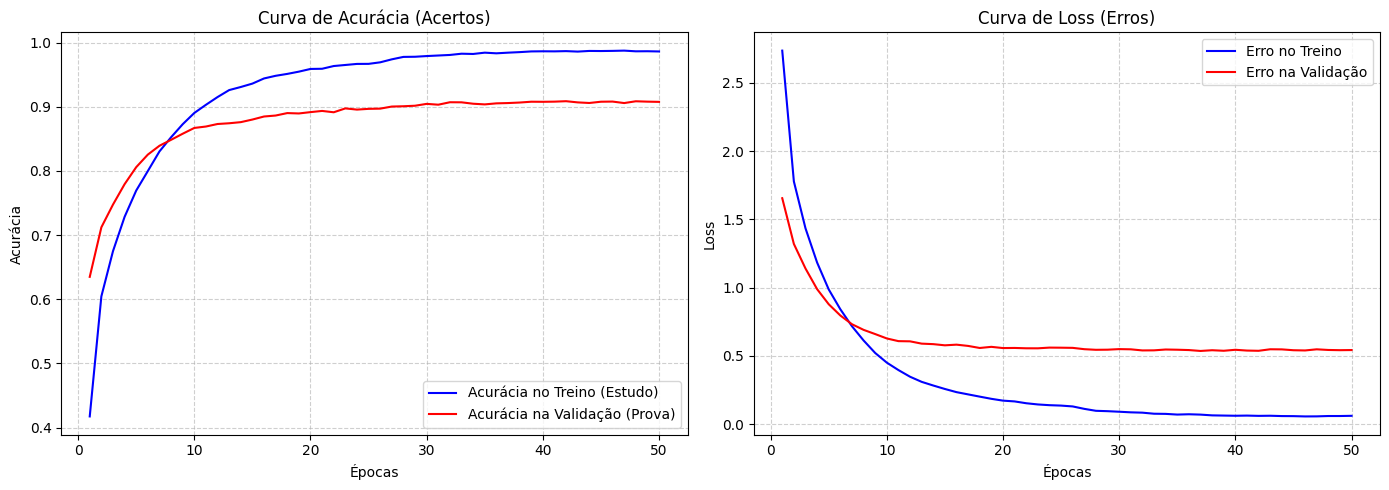

In [28]:
# Gráfico de aprendizado

# Extrai os dados da variável 'historico' gerada no passo anterior
acc = historico_v3.history['accuracy']
val_acc = historico_v3.history['val_accuracy']
loss = historico_v3.history['loss']
val_loss = historico_v3.history['val_loss']
epocas = range(1, len(acc) + 1)

# Cria uma figura com dois gráficos lado a lado
plt.figure(figsize=(14, 5))

# Gráfico 1: Acurácia (Precisamos que a linha suba e estabilize)
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Acurácia no Treino (Estudo)')
plt.plot(epocas, val_acc, 'r-', label='Acurácia na Validação (Prova)')
plt.title('Curva de Acurácia (Acertos)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Loss (Precisamos que a linha caia e aproxime de zero)
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Erro no Treino')
plt.plot(epocas, val_loss, 'r-', label='Erro na Validação')
plt.title('Curva de Loss (Erros)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [29]:
# Matriz de confusão
print("Realizando predições no dataset de validação. Aguarde...")

y_true = []
y_pred = []

# Itera sobre todos os lotes de imagens separadas para validação
for imagens, labels in dataset_validacao:
    previsoes = modelo.predict(imagens, verbose=0)
    # Pega o índice da classe com a maior probabilidade (Ex: 99% Bem-te-vi)
    classes_previstas = np.argmax(previsoes, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(classes_previstas)

print("\n=======================================================")
print("             RELATÓRIO DE CLASSIFICAÇÃO                ")
print("=======================================================")
# Imprime as métricas completas para cada espécie
# (Ocultamos os avisos de classes com zero previsões para deixar o log limpo)
import warnings
warnings.filterwarnings('ignore')

relatorio = classification_report(y_true, y_pred, target_names=nomes_das_especies)
print(relatorio)

# ==========================================
# GERANDO A MATRIZ DE CONFUSÃO
# ==========================================
# Calcula a matriz matemática
matriz = confusion_matrix(y_true, y_pred)

# Para 216 espécies, a imagem precisa ser bem grande
# plt.figure(figsize=(20, 18))
# # Usamos uma paleta de cores 'Blues'. O vmax limita a cor para destacar os erros.
# sns.heatmap(matriz, annot=False, cmap='Blues',
#             xticklabels=nomes_das_especies,
#             yticklabels=nomes_das_especies)

# plt.title('Matriz de Confusão - Identificação de Aves', fontsize=16)
# plt.ylabel('Espécie Real', fontsize=12)
# plt.xlabel('Espécie Prevista pela IA', fontsize=12)

# # Remove os rótulos do eixo X e Y se ficarem muito poluídos (opcional)
# plt.xticks(rotation=90, fontsize=6)
# plt.yticks(fontsize=6)

# plt.show()

Realizando predições no dataset de validação. Aguarde...

             RELATÓRIO DE CLASSIFICAÇÃO                
                                precision    recall  f1-score   support

               Amazona_vinacea       0.88      0.90      0.89        49
            Anabazenops_fuscus       0.94      0.85      0.89        39
              Anthus_hellmayri       1.00      0.93      0.96        28
             Aramides_saracura       0.95      0.88      0.92        43
         Arremon_semitorquatus       0.92      0.92      0.92        37
             Asthenes_moreirae       0.91      0.86      0.89        37
            Attila_phoenicurus       0.92      0.92      0.92        38
                  Attila_rufus       0.89      0.88      0.88        48
      Automolus_leucophthalmus       0.95      0.83      0.89        48
    Baryphthengus_ruficapillus       1.00      0.98      0.99        45
      Basileuterus_culicivorus       0.92      0.92      0.92        49
                Batar

In [30]:
# Pega a matriz que você já gerou no código anterior
matriz_erros = matriz.copy()

# Zera a diagonal principal (que são os acertos) para olharmos só para os erros
np.fill_diagonal(matriz_erros, 0)

print("TOP 10 CONFUSÕES DO MODELO:\n")
# Pega os índices dos maiores valores na matriz
indices_maiores_erros = np.argsort(matriz_erros, axis=None)[-20:][::-1]

for idx in indices_maiores_erros:
    linha = idx // len(nomes_das_especies)
    coluna = idx % len(nomes_das_especies)

    especie_real = nomes_das_especies[linha]
    especie_prevista = nomes_das_especies[coluna]
    quantidade_erros = matriz_erros[linha, coluna]

    print(f"O modelo achou que era {especie_prevista}, mas na verdade era {especie_real} ({quantidade_erros} vezes)")

TOP 10 CONFUSÕES DO MODELO:

O modelo achou que era Picumnus_cirratus, mas na verdade era Picumnus_temminckii (3 vezes)
O modelo achou que era Campephilus_robustus, mas na verdade era Phylloscartes_ventralis (3 vezes)
O modelo achou que era Euphonia_pectoralis, mas na verdade era Syndactyla_rufosuperciliata (2 vezes)
O modelo achou que era Colaptes_melanochloros, mas na verdade era Anabazenops_fuscus (2 vezes)
O modelo achou que era Picumnus_cirratus, mas na verdade era Cranioleuca_obsoleta (2 vezes)
O modelo achou que era Grallaria_varia, mas na verdade era Patagioenas_plumbea (2 vezes)
O modelo achou que era Drymophila_malura, mas na verdade era Sporophila_falcirostris (2 vezes)
O modelo achou que era Chiroxiphia_caudata, mas na verdade era Dysithamnus_stictothorax (2 vezes)
O modelo achou que era Pitangus_sulphuratus, mas na verdade era Xiphocolaptes_albicollis (2 vezes)
O modelo achou que era Chiroxiphia_caudata, mas na verdade era Aramides_saracura (2 vezes)
O modelo achou que era